# LeetCode #95: Unique Binary Search Trees II

https://leetcode.com/problems/unique-binary-search-trees-ii/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Brute force (permutations) | Exponential | O(n!) | Generate all, filter valid BSTs |
| **Divide-and-Conquer (Generate) ★** | **O(4ⁿ/√n)** | **O(n·Cₙ)** | Pick each root, recurse on left/right ranges |

---

## Understanding the Methods

### Brute Force
Generate all permutations of 1..n, check each forms a valid BST. Extremely wasteful.

### Optimal: Divide-and-Conquer ★
Key insight: every integer i in [lo, hi] can be the root.
- Left subtree uses values [lo..i-1]
- Right subtree uses values [i+1..hi]

Recursion: `Generate(lo, hi)`:
1. Base case: lo > hi → return [null] (one "nothing" option).
2. For each root i: compute all left subtrees and all right subtrees; create a node for each combination.

The total output size is the Catalan number C(n) = (2n choose n) / (n+1).

Optional: memoize `Generate(lo, hi)` with a dictionary; same range produces same set of trees.

**Constraints:**
* 1 <= n <= 8

## Solutions

### C#

In [ ]:
public class Solution {
    public IList<TreeNode> GenerateTrees(int n) {
        return Generate(1, n);
    }

    private IList<TreeNode> Generate(int lo, int hi) {
        var result = new List<TreeNode>();
        if (lo > hi) {
            result.Add(null); // null as a valid child
            return result;
        }
        for (int i = lo; i <= hi; i++) {
            foreach (var left in Generate(lo, i - 1))
                foreach (var right in Generate(i + 1, hi))
                    result.Add(new TreeNode(i, left, right));
        }
        return result;
    }
}

### Python

In [ ]:
class Solution:
    def generateTrees(self, n: int):
        def generate(lo, hi):
            if lo > hi:
                return [None]
            result = []
            for i in range(lo, hi + 1):
                for left in generate(lo, i - 1):
                    for right in generate(i + 1, hi):
                        node = TreeNode(i)
                        node.left = left
                        node.right = right
                        result.append(node)
            return result

        return generate(1, n)

### Go

In [ ]:
func generateTrees(n int) []*TreeNode {
    var generate func(lo, hi int) []*TreeNode
    generate = func(lo, hi int) []*TreeNode {
        if lo > hi {
            return []*TreeNode{nil}
        }
        var result []*TreeNode
        for i := lo; i <= hi; i++ {
            for _, left := range generate(lo, i-1) {
                for _, right := range generate(i+1, hi) {
                    result = append(result, &TreeNode{Val: i, Left: left, Right: right})
                }
            }
        }
        return result
    }
    return generate(1, n)
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;

impl Solution {
    pub fn generate_trees(n: i32) -> Vec<Option<Rc<RefCell<TreeNode>>>> {
        Self::generate(1, n)
    }

    fn generate(lo: i32, hi: i32) -> Vec<Option<Rc<RefCell<TreeNode>>>> {
        if lo > hi {
            return vec![None];
        }
        let mut result = Vec::new();
        for i in lo..=hi {
            for left in Self::generate(lo, i - 1) {
                for right in Self::generate(i + 1, hi) {
                    result.push(Some(Rc::new(RefCell::new(TreeNode {
                        val: i,
                        left: left.clone(),
                        right: right.clone(),
                    }))));
                }
            }
        }
        result
    }
}

## Example Scenarios

### 1. Common Case — n = 3 (Five Unique BSTs)
**Input:** `n = 3`

Try each root $i \in \{1,2,3\}$. Root=1: left=[], right=generate(2,3) → 2 trees. Root=2: left=[1], right=[3] → 1 tree. Root=3: left=generate(1,2), right=[] → 2 trees. Total = 5 = $C_3$.

*Why tricky:* Standard case confirming the Catalan count. Each root produces a different number of left/right subtree combinations.

$C_3 = \frac{1}{4}\binom{6}{3} = 5$ unique BSTs.

**Output:** 5 unique BSTs

---

### 2. Slightly Complex — n = 4 (14 Unique BSTs)
**Input:** `n = 4`

Root=1: $1 \times C_3 = 5$. Root=2: $C_1 \times C_2 = 2$. Root=3: $C_2 \times C_1 = 2$. Root=4: $C_3 \times 1 = 5$. Total $= 5+2+2+5 = 14$.

*Why tricky:* Larger n shows how subtree counts multiply. Multiple roots produce different combination counts. Memoization of generate(lo,hi) avoids recomputing shared ranges.

$C_4 = \frac{1}{5}\binom{8}{4} = 14$.

**Output:** 14 unique BSTs

---

### 3. Edge Case: Time Factor — n = 8 (Maximum, 1430 Trees)
**Input:** `n = 8`

Maximum constraint. Must generate all $C_8 = 1430$ structurally unique BSTs. Each tree has 8 nodes, so total node objects $= 1430 \times 8 = 11{,}440$. Without memoization, redundant subproblems explode.

*Why tricky:* Worst-case time and output size. With memo, each unique (lo,hi) pair is computed once; unique pairs $\leq \binom{9}{2} + 9 = 45$.

$C_8 = \frac{1}{9}\binom{16}{8} = 1430$. Total output nodes $= 11{,}440$.

**Output:** 1430 unique BSTs

---

### 4. Edge Case: Space Factor — n = 1 (Minimal)
**Input:** `n = 1`

generate(1,1): only root=1. Left = generate(1,0) = [null]. Right = generate(2,1) = [null]. One tree: single node [1]. Minimal memory: 1 TreeNode allocated.

*Why tricky:* Minimum input tests base cases lo > hi returning [null] correctly and that a single-node tree is properly constructed.

$C_1 = 1$. One tree, one node. $O(1)$ output space.

**Output:** `[[1]]`

---

### 5. Almost-Impossible but Plausible — n = 7, Skewed Among 429
**Input:** `n = 7`

Among $C_7 = 429$ trees, exactly 2 are maximally skewed: the all-left chain ($7 \to 6 \to \ldots \to 1$) and the all-right chain ($1 \to 2 \to \ldots \to 7$). Each has height $= n$. The generator produces both with no special handling — they arise when root picks extreme values.

*Why tricky:* Skewed trees have depth $= n$ (worst for traversals). Confirms the generator handles chains alongside balanced trees without subtree pointer aliasing bugs.

Skewed fraction $= 2/429 \approx 0.47\%$. Balanced height $= 3$; skewed height $= 7$.

**Output:** 429 unique BSTs (includes 2 maximally skewed)

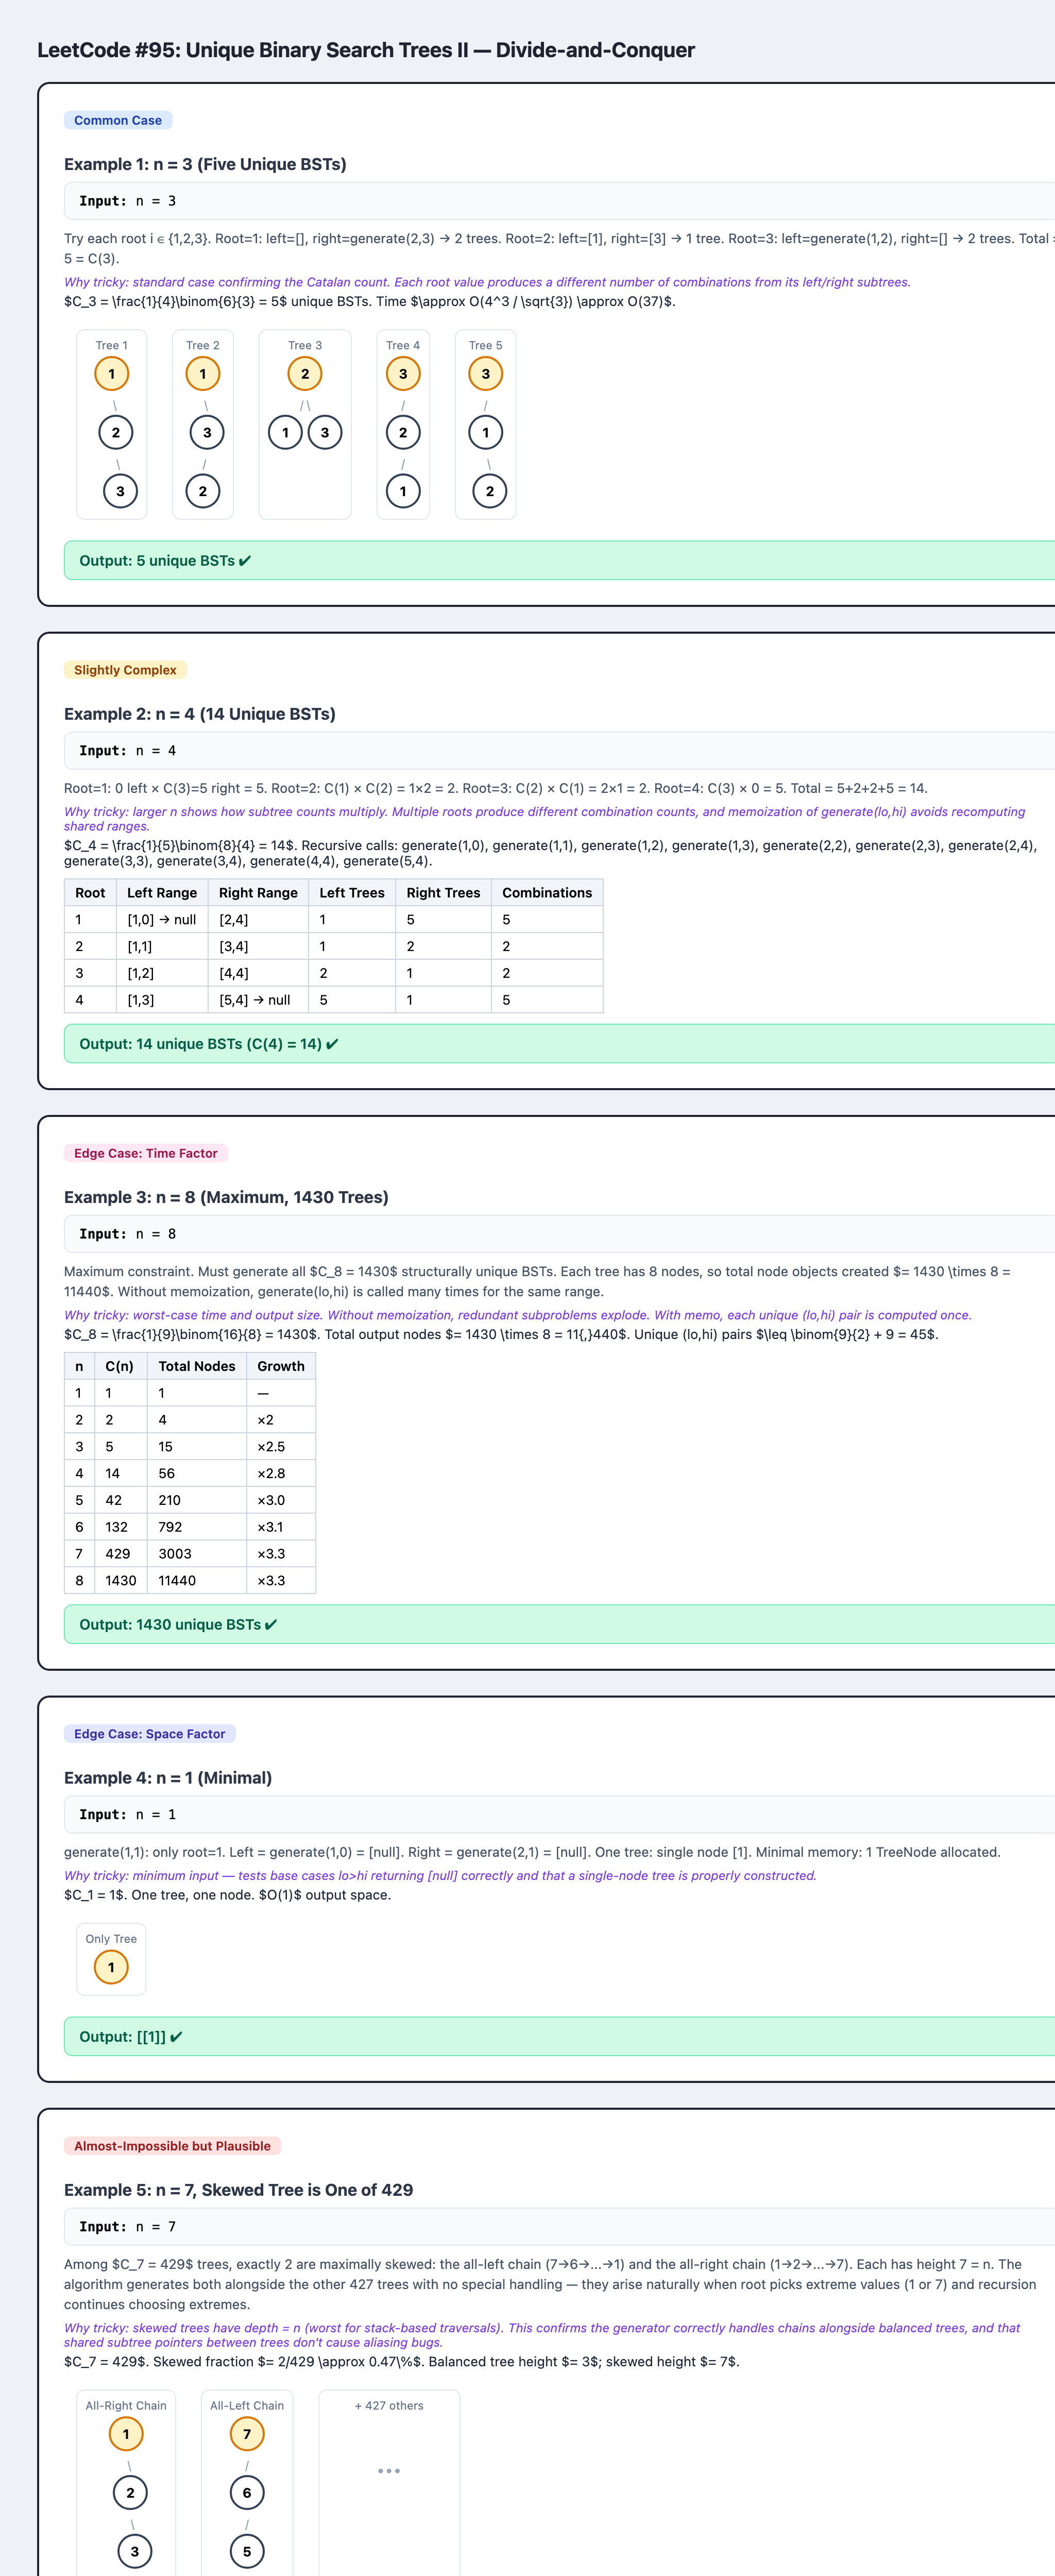